In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import json
import numpy as np

loc = Path.cwd()

print(loc)
json_file=[]

/home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performenceCompare


In [2]:
imgNetF = loc / "alexnet_data"

# Find and read all JSON files recursively
for file_path in imgNetF.rglob("*.json"):
    print(f"Found: {file_path}")
    json_file.append(file_path)
        



Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performenceCompare/alexnet_data/inat_alexnet_500_ptclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performenceCompare/alexnet_data/inat_alexnet_500_npclasses_imagenet_history.json


In [3]:

json_data=[]
# Find and read all JSON files recursively
for file_path in json_file:    
    print(file_path.name)
    try:
        # read_text() reads content; json.loads() parses it
        data = json.loads(file_path.read_text(encoding="utf-8"))
        print(data)
        json_data.append(data)
        # Process your data here
    except json.JSONDecodeError:
        print(f"Error: {file_path.name} is not a valid JSON file.")

model_name_pth = {
    "inat_alexnet_500_ptclasses_imagenet.pth": "AlexNet pretrained model",
    "inat_alexnet_500_npclasses_imagenet.pth": "AlexNet random start model",
}

# derive the equivalent mapping keyed by history-json filename
model_name = {
    Path(pth_name).stem + "_history.json": label
    for pth_name, label in model_name_pth.items()
}

assert len(model_name.keys()) == len(json_file), (
    f"Expected {len(model_name)} json files, found {len(json_file)}: "
    f"{[f.name for f in json_file]}"
)

inat_alexnet_500_ptclasses_imagenet_history.json
{'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'train_loss': [1.103799746322632, 1.098703081893921, 1.0937061561584474, 1.0903940305709838, 1.0879110763549804, 1.0883481950759888, 1.0850850423812866, 1.0838872110366822, 1.0826017782211304, 1.0814921447753907, 1.0815152517318725, 1.0788695302963256, 1.080296105003357, 1.078973638343811, 1.0786156337738038, 1.0768417573928832, 1.0756819477081299, 1.0767834232330322, 1.0777612550735474, 1.0755747636795043], 'train_accuracy': [0.9997, 0.9997, 0.99995, 0.9999, 0.99995, 0.99985, 0.99995, 0.99995, 0.9999, 0.99995, 0.9998, 0.99985, 0.99995, 0.9998, 0.99995, 0.9999, 0.99995, 0.99995, 0.9999, 0.99995], 'val_loss': [3.2097790866851805, 3.2040872097015383, 3.2168277965545653, 3.218897258758545, 3.2272617637634275, 3.2184001194000245, 3.228303315734863, 3.227955379486084, 3.223523012161255, 3.232937494659424, 3.228497915649414, 3.2293683891296388, 3.229167449951171

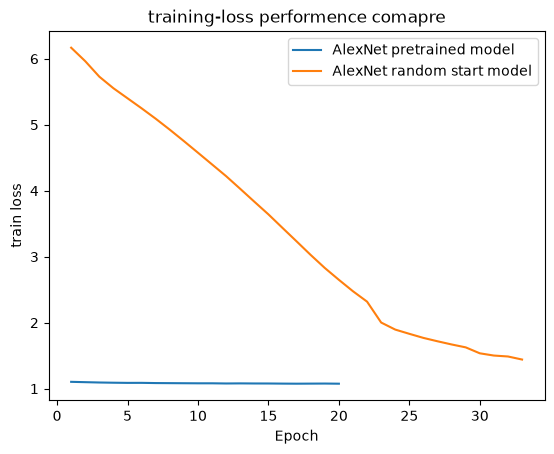

In [4]:
# train loss

for dt in range(len(json_data)):
    plt.plot(json_data[dt]["epoch"], json_data[dt]["train_loss"], label=model_name[json_file[dt].name], linestyle='-')

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("train loss")
plt.title("training-loss performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

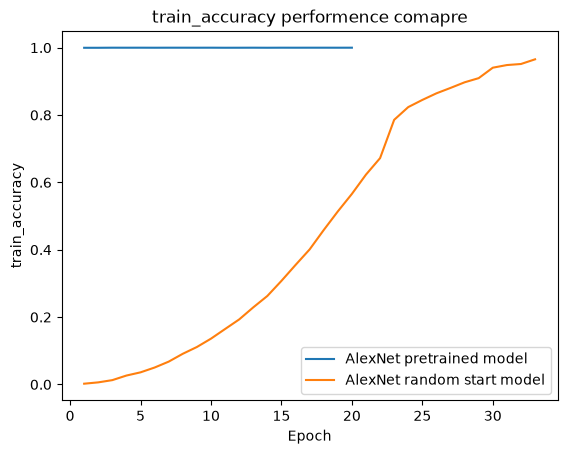

In [5]:
# train acc

for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['train_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("train_accuracy")
plt.title("train_accuracy performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

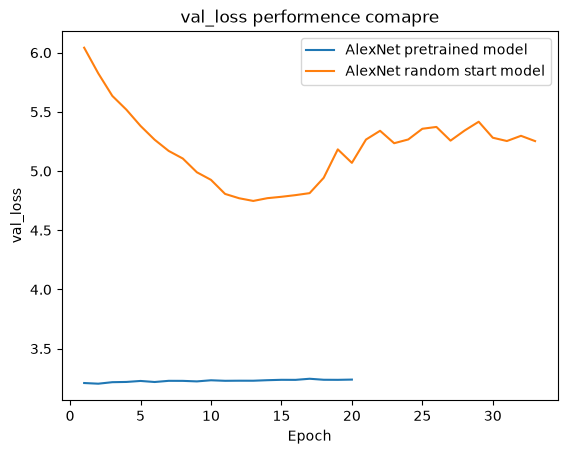

In [6]:
# val loss


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_loss'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("val_loss")
plt.title("val_loss performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

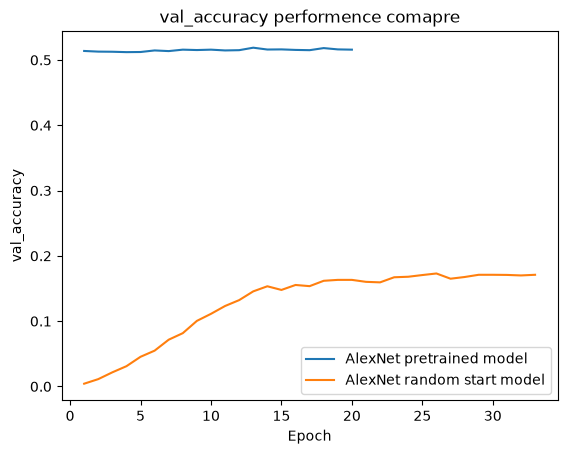

In [7]:
# train acc


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("val_accuracy")
plt.title("val_accuracy performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

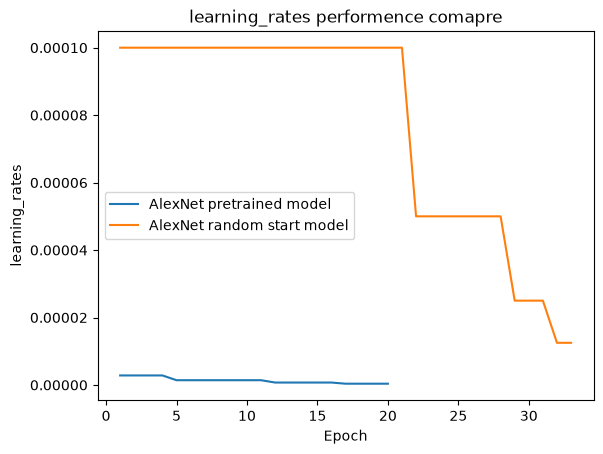

In [8]:
# learning rate

for dt in range(len(json_data)):
    if type(json_data[dt]['learning_rates'][0]) == list:
        row_averages = [sum(row) / len(row) for row in json_data[dt]['learning_rates']]
        plt.plot(json_data[dt]['epoch'], row_averages, label=model_name[json_file[dt].name], linestyle="-")

    else:
        plt.plot(json_data[dt]['epoch'], json_data[dt]['learning_rates'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("learning_rates")
plt.title("learning_rates performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib